In [33]:
import os, sys
import pandas as pd
from transformers import RobertaTokenizer
from datasets import Dataset
from collections import defaultdict

sys.path.append("../")
from utils.parameters import *


tokenizer1 = RobertaTokenizer.from_pretrained(TOKEN_DIR_BASE)
tokenizer2 = RobertaTokenizer.from_pretrained(TOKEN_DIR_BPE)

def load_and_preprocess_data(positive_file, negative_file, is_pseudo=False):
    '''
    用positive伪标签数据，补足原本标注数据的正例数量，同时减少标注负例数量，使得加上伪标签负例后，正负例数量相等
    '''
    # Load positive and negative samples
    if not is_pseudo:
        positive_samples = pd.read_csv(os.path.join(SAMPLES_PATH, positive_file), header=None, names=["sequence"])
        negative_samples = pd.read_csv(os.path.join(SAMPLES_PATH, negative_file), header=None, names=["sequence"])
    else:
        positive_samples = pd.read_csv(os.path.join(PSEUDO_SAMPLES_PATH, positive_file), header=None, names=["sequence"])
        negative_samples = pd.read_csv(os.path.join(PSEUDO_SAMPLES_PATH, negative_file), header=None, names=["sequence"])

    # Add labels
    positive_samples["labels"] = 1
    negative_samples["labels"] = 0

    # Concatenate the datasets
    data = pd.concat([positive_samples, negative_samples], ignore_index=True)

    # Convert to HuggingFace Dataset
    train_dataset = Dataset.from_pandas(data)

    # Tokenize the sequences
    def tokenize_function(examples):
        tokens1 = tokenizer1(examples["sequence"])
        tokens2 = tokenizer2(examples["sequence"])
        return {"input_ids_1": tokens1["input_ids"], "input_ids_2": tokens2["input_ids"]}
        # return {"input_ids_1": tokens1["input_ids"], "input_ids_2": tokens2["input_ids"], "attention_mask_1": tokens1["attention_mask"], "attention_mask_2": tokens2["attention_mask"]}

    tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)

    return tokenized_train_dataset

In [34]:
labeled_HEK293T_dataset = load_and_preprocess_data(
    "distinct_positive_samples_HEK293T.csv",
    "distinct_negative_samples_HEK293T.csv"
)

Map:   0%|          | 0/42425 [00:00<?, ? examples/s]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


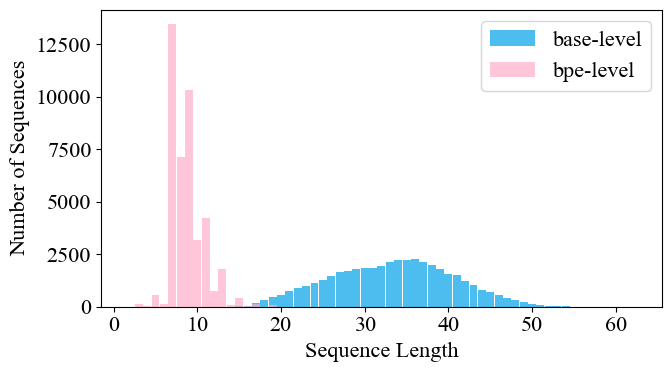

In [46]:
# 统计dataset 中，input_ids_1 和 input_ids_2 的长度分布
base_len_dict = defaultdict(int)
bpe_len_dict = defaultdict(int)
for i in range(len(labeled_HEK293T_dataset)):
    base_len_dict[len(labeled_HEK293T_dataset[i]["input_ids_1"])-2] += 1
    bpe_len_dict[len(labeled_HEK293T_dataset[i]["input_ids_2"])-2] += 1

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
plt.rc('font', family='Times New Roman')
plt.figure(figsize=(7, 4))
plt.bar(base_len_dict.keys(), base_len_dict.values(), color="#00A2E8", width=0.95, alpha=0.7, label="base-level")
plt.bar(bpe_len_dict.keys(), bpe_len_dict.values(), color="#FFAEC9", width=0.95, alpha=0.7, label="bpe-level")
plt.legend()
plt.xlabel("Sequence Length")
plt.ylabel("Number of Sequences")
plt.tight_layout()
plt.savefig("../figures/data_count/HEK293T.eps", format="eps", bbox_inches="tight")

In [36]:
labeled_WDLPS_dataset = load_and_preprocess_data(
    "distinct_positive_samples_WDLPS.csv",
    "distinct_negative_samples_WDLPS.csv"
)

Map:   0%|          | 0/3253 [00:00<?, ? examples/s]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


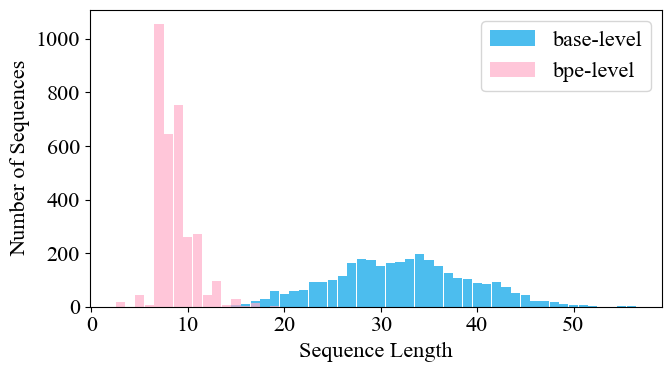

In [47]:
base_len_dict2 = defaultdict(int)
bpe_len_dict2 = defaultdict(int)
for i in range(len(labeled_WDLPS_dataset)):
    base_len_dict2[len(labeled_WDLPS_dataset[i]["input_ids_1"])-2] += 1
    bpe_len_dict2[len(labeled_WDLPS_dataset[i]["input_ids_2"])-2] += 1

plt.figure(figsize=(7, 4))
plt.bar(base_len_dict2.keys(), base_len_dict2.values(), color="#00A2E8", width=0.95, alpha=0.7, label="base-level")
plt.bar(bpe_len_dict2.keys(), bpe_len_dict2.values(), color="#FFAEC9", width=0.95, alpha=0.7, label="bpe-level")
plt.legend()
plt.xlabel("Sequence Length")
plt.ylabel("Number of Sequences")
plt.tight_layout()
plt.savefig("../figures/data_count/WDLPS.eps", format="eps", bbox_inches="tight")

In [38]:
pseudo_HEK293T_dataset = load_and_preprocess_data(
    "pseudo_positive_samples_HEK293T_v2.csv",
    "pseudo_negative_samples_HEK293T_v2.csv",
    is_pseudo=True
)

Map:   0%|          | 0/12413 [00:00<?, ? examples/s]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


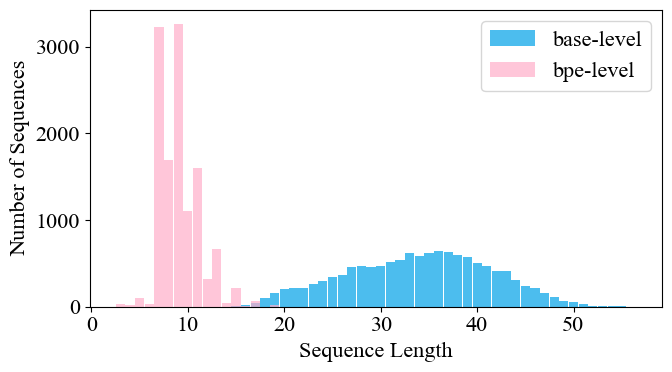

In [48]:
base_len_dict3 = defaultdict(int)
bpe_len_dict3 = defaultdict(int)
for i in range(len(pseudo_HEK293T_dataset)):
    base_len_dict3[len(pseudo_HEK293T_dataset[i]["input_ids_1"])-2] += 1
    bpe_len_dict3[len(pseudo_HEK293T_dataset[i]["input_ids_2"])-2] += 1

plt.figure(figsize=(7, 4))
plt.bar(base_len_dict3.keys(), base_len_dict3.values(), color="#00A2E8", width=0.95, alpha=0.7, label="base-level")
plt.bar(bpe_len_dict3.keys(), bpe_len_dict3.values(), color="#FFAEC9", width=0.95, alpha=0.7, label="bpe-level")
plt.legend()
plt.xlabel("Sequence Length")
plt.ylabel("Number of Sequences")
plt.tight_layout()
plt.savefig("../figures/data_count/pseudo_HEK293T.eps", format="eps", bbox_inches="tight")